In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset

import shap 
import json

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
device

device(type='mps')

In [11]:
dfs = get_dfs(os.path.dirname(os.getcwd()))
static_df = create_static_df(dfs)
medication_df = create_medication_df(dfs)
vitals_ca, vitals_lab = create_vitals_df(dfs)

ts_data = create_ts_data(vitals_ca, vitals_lab, medication_df, merge_lab=True, merge_med=True, static_df=static_df)
#forward_fill_imputation(ts_data) 

#notes = create_notes_df(dfs, filename='../data/embeddings/emb_gte.npy')
notes = create_notes_df(dfs, filename='../data/embeddings/emb_med_gte_simcse_en_ger.npy')
#notes = create_notes_df(dfs, filename=None)

full_dataset = NephroCAGEDataset(static_df=static_df, ts_data=ts_data, notes_df=notes, biopsy_df=dfs['biopsy'])
datapoints_limit = len(full_dataset)
#datapoints_limit = 320 
dataset = Subset(full_dataset, indices=list(range(datapoints_limit)))
ts_scaler = full_dataset.ts_scaler
static_scaler = full_dataset.scaler

Unique patients in medication: 3335
Removing patients that are not in static_df
Unique patients in clinical assessments: 3296
Average entries per patient 78.9
Unique patients in clinical assessments: 3465
Removing patients that are not in static_df
Unique patients in clinical assessments: 3423
Average entries per patient 61.16155419222904
Unique patients in lab df: 3460
Removing patients that are not in static_df
Unique patients in lab df: 3410
Average entries per patient 472.2140762463343
Reading notes from exams.csv
Found 206509 texts
Loading 215137 texts from clinical assessments
Concatenated texts and deleted NaNs, final count: 367140
Average texts per patient: 106.9


In [12]:
# Split dataset into training and test sets (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
print(test_size)

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

#vanilla_lstm = VanillaTimeSeriesEncoder()
att_encoder = TimeAwareAttentionEncoder(use_temporal_attention=True)
model = MultiModal(att_encoder, categorical_cardinalities=full_dataset.categorical_cardinalities, use_static=True, use_notes=True).to(device)

state_dict = torch.load('../models/after10epochs.pt', weights_only=True, map_location=torch.device('cpu'))
missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing:", missing)
print("Unexpected:", unexpected)

model.eval()
model.to(device)

677
Missing: ['lstm_encoder.lstm.lstm_cells.0.W_decomp', 'lstm_encoder.lstm.lstm_cells.0.b_decomp', 'lstm_encoder.lstm.lstm_cells.0.Wi', 'lstm_encoder.lstm.lstm_cells.0.Ui', 'lstm_encoder.lstm.lstm_cells.0.bi', 'lstm_encoder.lstm.lstm_cells.0.Wf', 'lstm_encoder.lstm.lstm_cells.0.Uf', 'lstm_encoder.lstm.lstm_cells.0.bf', 'lstm_encoder.lstm.lstm_cells.0.Wo', 'lstm_encoder.lstm.lstm_cells.0.Uo', 'lstm_encoder.lstm.lstm_cells.0.bo', 'lstm_encoder.lstm.lstm_cells.0.Wc', 'lstm_encoder.lstm.lstm_cells.0.Uc', 'lstm_encoder.lstm.lstm_cells.0.bc', 'lstm_encoder.lstm.lstm_cells.1.W_decomp', 'lstm_encoder.lstm.lstm_cells.1.b_decomp', 'lstm_encoder.lstm.lstm_cells.1.Wi', 'lstm_encoder.lstm.lstm_cells.1.Ui', 'lstm_encoder.lstm.lstm_cells.1.bi', 'lstm_encoder.lstm.lstm_cells.1.Wf', 'lstm_encoder.lstm.lstm_cells.1.Uf', 'lstm_encoder.lstm.lstm_cells.1.bf', 'lstm_encoder.lstm.lstm_cells.1.Wo', 'lstm_encoder.lstm.lstm_cells.1.Uo', 'lstm_encoder.lstm.lstm_cells.1.bo', 'lstm_encoder.lstm.lstm_cells.1.Wc', 

MultiModal(
  (lstm_encoder): TimeAwareAttentionEncoder(
    (lstm): TimeAwareLSTM(
      (lstm_cells): ModuleList(
        (0-1): 2 x TLSTMCell()
      )
    )
    (attention): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
    )
    (layer_norm_1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=512, out_features=2048, bias=True)
      (1): ReLU()
      (2): Linear(in_features=2048, out_features=512, bias=True)
    )
    (layer_norm_2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (static_encoder): StaticEncoder(
    (embeddings): ModuleList(
      (0): Embedding(2, 16)
      (1): Embedding(491, 16)
      (2): Embedding(9, 16)
      (3): Embedding(2, 16)
      (4): Embedding(9, 16)
      (5): Embedding(3, 16)
    )
    (numerical_processor): Sequential(
      (0): Linear(in_features=9, out_features=16, bias=True)
      (1): ReLU()
    )
    (fc

In [13]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # 1 output for binary classification

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x.squeeze(-1)

In [14]:
task = "GraftLoss" 
clf_model = SimpleMLP(input_dim=512)
clf_model.load_state_dict(torch.load(f"../models/{task}@90_clf.pth", weights_only=True))
clf_model.eval()
clf_model.to(device)

SimpleMLP(
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
num_cat   = len(CONFIG['static_categorical_cols'])
num_num   = len(CONFIG['static_numerical_cols'])
F         = len(CONFIG['ts_features'])
CONFIG['max_notes'] = 100

feature_names = (
    CONFIG['static_numerical_cols'] +
    CONFIG['ts_features'] +
    ['notes_embedding_mean']
)
#['age', 'number_dialyses', 'cold_ischemia_time', 'age_donor', 'pirche_score', 'mma_broad', 'mmb_broad', 'mmdr_broad', 'mm_broad', 'bp_sys', 'bp_dia', 'weight', 'urine_volume', 'hr', 'temperature', 'diuresis_time', 'creatinine', 'leukocyte', 'proteinuria', 'crphp', 'egfr', 'acr', 'Tacrolimus', 'Methylprednisolon', 'Ciclosporin', 'notes_embedding_mean']

feature_name_mapping = {
    'age': 'Age (recipient)',
    'gender': 'Gender (recipient)',
    'underlying_disease': 'Underlying disease',
    'blood_group': 'Blood group (recipient)',
    'cold_ischemia_time': 'Cold ischemia time',
    'gender_donor': 'Gender (donor)',
    'age_donor': 'Age (donor)',
    'donor_bloodgroup': 'Blood group (donor)',
    'type_of_donation': 'Type of donation',
    'pirche_score': 'PIRCHE score',
    'mm_broad': 'Broad antigen mismatch',
    'mma_broad': 'A Broad antigen mismatch',
    'mmdr_broad': 'DR Broad antigen mismatch',
    'mmb_broad': 'B Broad antigen mismatch',
    'Heart rate': 'Heart rate',
    'hr': 'Heart rate',
    'Blood pressure': 'Blood pressure',
    'bp_sys': 'Systolic blood pressure',
    'bp_dia': 'Diastolic blood pressure',
    'weight': 'Weight',
    'Temperature': 'Temperature',
    'temperature': 'Temperature',
    'urine_volume': 'Urine volume',
    'creatinine': 'Creatinine',
    'leukocyte': 'Leukocyte',
    'c-reactive protein': 'C-Reactive protein',
    'crphp': 'C-Reactive protein',
    'proteinuria': 'Proteinuria',
    'acr': 'ACR',
    'ACR': 'ACR',
    'egfr': 'eGFR',
    'Tacrolimus': 'Tacrolimus',
    'Methylprednisolon': 'Methylprednisolone',
    'Ciclosporin': 'Ciclosporin',
    'number_dialyses': 'Number of dialyses',
    'diuresis_time': 'Diuresis time',
    'Notes embeddings': 'Notes embeddings',
    'Underlying disease': 'Underlying disease',
    'notes_embedding_mean': 'Clinical Notes'
}

if task == "GraftLoss":
    feature_importance = {'hr': 5, 'gender': 5, 'gender_donor': 5, 'temperature': 5, 'leukocyte': 5, 'donor_bloodgroup': 4, 'number_dialyses': 4, 'Methylprednisolon': 4, 'blood_group': 4, 'bp_sys': 4, 'crphp': 3, 'Ciclosporin': 3, 'weight': 3, 'pirche_score': 3, 'age': 3, 'age_donor': 2, 'cold_ischemia_time': 2, 'Tacrolimus': 2, 'proteinuria': 2, 'acr': 2, 'type_of_donation': 1, 'mm_broad': 1, 'mma_broad': 1, 'mmdr_broad': 1, 'mmb_broad': 1, 'urine_volume': 1, 'egfr': 1, 'creatinine': 1, "notes_embedding_mean": 0}
if task == "Mortality":
    feature_importance = {'hr': 1, 'gender': 4, 'gender_donor': 5, 'temperature': 1, 'leukocyte': 2, 'donor_bloodgroup': 5, 'number_dialyses': 2, 'Methylprednisolon': 4, 'blood_group': 5, 'bp_sys': 1, 'crphp': 1, 'Ciclosporin': 4, 'weight': 3, 'pirche_score': 4, 'age': 1, 'age_donor': 2, 'cold_ischemia_time': 4, 'Tacrolimus': 4, 'proteinuria': 3, 'acr': 3, 'type_of_donation': 3, 'mm_broad': 4, 'mma_broad': 4, 'mmdr_broad': 4, 'mmb_broad': 4, 'urine_volume': 3, 'egfr': 2, 'creatinine': 2, "notes_embedding_mean": 0}
if task == "Rejection":
    feature_importance = {'hr': 5, 'gender': 3, 'gender_donor': 4, 'temperature': 4, 'leukocyte': 5, 'donor_bloodgroup': 3, 'number_dialyses': 5, 'Methylprednisolon': 3, 'blood_group': 3, 'bp_sys': 1, 'crphp': 4, 'Ciclosporin': 3, 'weight': 4, 'pirche_score': 3, 'age': 2, 'age_donor': 3, 'cold_ischemia_time': 1, 'Tacrolimus': 1, 'proteinuria': 1, 'acr': 3, 'type_of_donation': 1, 'mm_broad': 1, 'mma_broad': 1, 'mmdr_broad': 1, 'mmb_broad': 1, 'urine_volume': 1, 'egfr': 2, 'creatinine': 1, "notes_embedding_mean": 0}


In [17]:
def pipeline_predict(static_cat, static_num, ts_feats, timesteps, mask, notes_embeddings, notes_timesteps, notes_mask, T_max):
    """
    Runs a forward pass (model -> clf_model). 
    Returns shape (B,) with probabilities.
    """
    B = static_cat.size(0)
    T_eff = T_max-1
    if T_eff <= 0:
        raise ValueError(f"T_eff={T_eff} must be > 0. Check T_max vs predict_steps_ahead.")
    # Ensure the data is on the right device
    static_cat = static_cat.to(device)
    static_num = static_num.to(device)
    ts_feats   = ts_feats.to(device)
    timesteps  = timesteps.to(device)
    mask       = mask.to(device)

    notes_embeddings = notes_embeddings.to(device)
    notes_timesteps = notes_timesteps.to(device)
    notes_mask = notes_mask.to(device)

    # Make sure the feature dimensions are correct
    ts_feats = ts_feats[:, :T_eff, :]
    timesteps = timesteps[:, :T_eff]
    mask = mask[:, :T_eff]

    if T_eff > 1:
        intervals = timesteps[:, 1:] - timesteps[:, :-1]
    else:
        intervals = torch.zeros((B, 0), device=device)

    dummy_col = torch.zeros((B, 1), device=device, dtype=intervals.dtype)
    elapsed_times = torch.cat([intervals, dummy_col], dim=1)

    pred_ts, lstm_out, _, _ = model(
        x=ts_feats,
        elapsed_times=elapsed_times,
        timesteps=timesteps,
        static_features=(static_cat, static_num),
        mask=mask,
        notes_embeddings=notes_embeddings,
        notes_timesteps=notes_timesteps,
        notes_mask=notes_mask
    )
    final_h = lstm_out[:, -1, :]
    logits = clf_model(final_h)
    probs = torch.sigmoid(logits).flatten()
    return probs


def sample_temporal_mask(T, num_segments):
    seg_size = T // num_segments
    mask = torch.ones(T, device=device)

    for s in range(num_segments):
        if torch.rand(1) > 0.5:
            start = s * seg_size
            end = T if s == num_segments - 1 else (s + 1) * seg_size
            mask[start:end] = 0

    return mask

def apply_temporal_mask(interpolated_inputs, mask, fixed_inputs):
    mask = mask.view(1, fixed_inputs.shape[1])
    while mask.dim() < interpolated_inputs.dim():
        mask = mask.unsqueeze(-1)

    return mask * interpolated_inputs + (1 - mask) * fixed_inputs

def interpolate(baseline, sample, alpha):
    delta = sample - baseline
    return baseline + alpha * delta

def compute_gradient(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask, model, T_max):
    
    #print(f"sc: {sc} \nsn: {sn} \ntf: {tf} \nt:{t} \nm: {m} \nnt: {nt} \nnt_timesteps: {nt_timesteps} \nnt_mask: {nt_mask}")

    probs = pipeline_predict(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask, T_max)
    #print(f"Probability after interpolation {probs}")
    #print(f"sn.shape: {sn.shape}, tf.shape: {tf.shape}, nt.shape: {nt.shape}")
    grads = torch.autograd.grad(
        outputs=probs,
        inputs=[sn, tf, nt],
        grad_outputs=torch.ones_like(probs),
        create_graph=False,
        retain_graph=False,
        only_inputs=True
    )
    x, y, z = grads
    #print(x, y, z)
    return grads, probs

def integral_approximation(gradients):
    # Riemann trapezoidal rule
    grads = (gradients[:-1] + gradients[1:]) / 2.0
    integrated_gradients = torch.mean(grads, dim=0)
    return integrated_gradients

def integrated_gradients(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask, model, m_steps, num_segments=None, T_max=20):
    interpolations = []
    grads = []

    alphas = torch.linspace(start=0.0, end=1.0, steps=m_steps+1, device=device)
    sn_baseline = torch.zeros_like(sn)
    tf_baseline = torch.zeros_like(tf)
    nt_baseline = torch.zeros_like(nt)
    all_probs = []

    for i in alphas:
        x = interpolate(sn_baseline, sn, i)
        y = interpolate(tf_baseline, tf, i)
        z = interpolate(nt_baseline, nt, i)

        if num_segments != None:
            x_mask = sample_temporal_mask(x.shape[1], num_segments)
            x = apply_temporal_mask(x, x_mask, sn)
            y_mask = sample_temporal_mask(y.shape[1], num_segments)
            y = apply_temporal_mask(y, y_mask, tf)
            z_mask = sample_temporal_mask(z.shape[1], num_segments)
            z = apply_temporal_mask(z, z_mask, nt)

        (x_grad, y_grad, z_grad), probs = compute_gradient(sc, x, y, t, m, z, nt_timesteps, nt_mask, model, T_max)
        
        g_x_flat = x_grad.reshape(-1)
        g_y_flat = y_grad.reshape(-1)
        g_z_flat = z_grad.reshape(-1)

        # Concatenate into a single 1D vector
        grad_flat = torch.cat([g_x_flat, g_y_flat, g_z_flat], dim=0)
        grads.append(grad_flat)
        all_probs.append(probs)
    
    avg_gradients = integral_approximation(torch.stack(grads,dim=0))
    sample, shape = flatten_tensors([sn, tf, nt])
    integrated_gradients = (sample) * avg_gradients.reshape(-1) # Formula normaly is (sample - baseline) * avg_gradients, but since baseline is 0 it can be ommitted for easier data transformation

    #delta_f = integrated_gradients.sum() / (all_probs[-1].item() - all_probs[0].item())
    #print(f"Completeness ratio: {delta_f}")
    delta = all_probs[-1].item() - all_probs[0].item()
    rel_error = abs(integrated_gradients.sum() - delta) / (delta + 1e-8)
    #print(f"Error for sample: {rel_error}", end=" - ")
    if num_segments!=None:
        #print(f"TIMING IS ENABLE AND BREAKS COMPLETENESS AXIOM", end=" - ")
        pass

    return integrated_gradients, shape

def flatten_tensors(tensors):
    """
    Takes a list of tensors of arbitrary shapes and returns:
    - flat_vector: a 1D tensor containing all flattened values
    - shapes: a list of shapes (and sizes) required to restore them later
    """
    shapes = [t.shape for t in tensors]
    flat = torch.cat([t.reshape(-1) for t in tensors])
    return flat, shapes

def unflatten_tensors(flat_vector, shapes):
    """
    Reconstructs tensors from `flat_vector` using the saved `shapes`.
    Returns a list of tensors with original shapes.
    """
    tensors = []
    index = 0
    for shape in shapes:
        numel = torch.tensor(shape).prod().item()
        chunk = flat_vector[index:index+numel]
        tensors.append(chunk.reshape(shape))
        index += numel
    return tensors


def run_ig(test_dataloader, model, max_samples=5, m_steps=10, num_segments=None, T_max=20):
    """
    Run Integrated Gradients for multiple samples
    """
    all_ig_agg = []
    sample_count = 0
    
    for batch in test_dataloader:
        B = batch['static_categorical_features'].size(0)
        for i in range(B):
            if sample_count >= max_samples:
                break

            sc = batch['static_categorical_features'][i:i+1]
            sn = batch['static_numerical_features'][i:i+1]
            tf = batch['ts_features'][i:i+1]
            t = batch['timesteps'][i:i+1]
            m = batch['mask'][i:i+1]
            nt = batch['notes_embeddings'][i:i+1]
            nt_timesteps = batch['notes_timesteps'][i:i+1]
            nt_mask = batch['notes_mask'][i:i+1]
            #print(f"Probability before interpolation: {pipeline_predict(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask)}")

            sc = sc.to(device) 
            sn = sn.to(device)
            tf = tf.to(device)
            t = t.to(device)
            m = m.to(device)
            nt = nt.to(device)
            nt_timesteps = nt_timesteps.to(device)
            nt_mask = nt_mask.to(device)

            sn.requires_grad_(True)
            tf.requires_grad_(True)
            nt.requires_grad_(True)

            #print(nt_timesteps.shape, nt.shape)
            #print(f"sc: {sc} \nsn: {sn} \n tf: {tf} \nt:{t} \nm: {m} \nnt: {nt} \nnt_timesteps: {nt_timesteps} \nnt_mask: {nt_mask}")
            #sample, shapes = flatten_tensors([sc, sn, tf, t, m, nt, nt_timesteps, nt_mask])
            sample, shapes = flatten_tensors([sc, sn, tf, nt]) #maskless
            # Flatten test sample
            #test_feats = flatten_sample_only_feats(sc, sn, tf, nt, nt_timesteps, nt_mask).reshape(1, -1)
            #sample = torch.from_numpy(test_feats)
            ig_agg_i, shape = integrated_gradients(sc, sn, tf, t, m, nt, nt_timesteps, nt_mask, model, m_steps, num_segments, T_max)
            x, y, z = unflatten_tensors(ig_agg_i, shape)
            #print(f"x.shape: {x.shape}, y.shape: {y.shape}, z.shape: {z.shape}") # x is 9 feat. on stat_numerical, y is 16 feat. in ts over 523 timesteps, and mean of z is mean_note_emebddings, summing up to all expected 26 features
            all_ig_agg.append((ig_agg_i, shape))
            sample_count += 1
            print(f"Processed sample {sample_count}/{max_samples}")
            
        if sample_count >= max_samples:
            break
            
    return all_ig_agg    

In [19]:
#Calc IG
samples = 50 #test_size
m_steps = 300
T_max = 30
version = "IG"
for num_segments in [None]:
    res = run_ig(test_dataloader, clf_model, samples, m_steps, num_segments=num_segments, T_max=T_max)

    sn_tensors = []
    tf_tensors = []
    nt_tensors = []

    for item in res: 
        x, y, z = unflatten_tensors(item[0], item[1])
        #print(f"x.shape: {x.shape}, y.shape: {y.shape}") #: x.shape: torch.Size([1, 9]), y.shape: torch.Size([1, 258, 16]), z.shape: torch.Size([1, 262, 1024])
        sn_tensors.append(x.abs().squeeze(0))
        tf_tensors.append(y.abs().sum(dim=(1)))
        nt_tensors.append(z.abs().sum(dim=(1)))

    sn_mean = (torch.stack(sn_tensors, dim=0)).mean(dim=0)
    tf_mean = (torch.cat(tf_tensors, dim=0)).mean(dim=0)
    nt_mean = (torch.cat(nt_tensors, dim=0)).mean(dim=0).sum()

    sn_mean_flat = sn_mean.detach().cpu().numpy()
    tf_mean_flat = tf_mean.detach().cpu().numpy()
    nt_flat = nt_mean.detach().unsqueeze(0).cpu().numpy() #Sum to convert from 1024 embedding attributions to 1 attribution for all notes in general
    all_data = np.concatenate((sn_mean_flat, tf_mean_flat, nt_flat))

    sorted_scores, sorted_names = zip(*sorted(zip(all_data, feature_names)))
    sorted_scores = list(sorted_scores)
    sorted_names = list(sorted_names)
    i=0
    while i < len(sorted_names):
        if sorted_names[i] in ['bp_dia', 'mmdr_broad', 'mmb_broad', 'mma_broad', 'diuresis_time']:
            sorted_scores.pop(i)
            sorted_names.pop(i)
            i-=1
        i+=1

    names = [feature_name_mapping[x] for x in sorted_names]

    sorted_importance = []
    for i in range(0, len(sorted_names)):
        importance = feature_importance.get(sorted_names[i])
        sorted_importance.append(importance)
    if num_segments is not None:
        version = "TIMING"
    path = f"../results/{version}_{task.replace(' ', '_')}_feature_importance_{samples}samples_T{T_max}"

    formated_results = [
        {"Feature": name, "IG Value": x.item(), "Clinical Rating": rating}
        for name, x, rating in zip(names, sorted_scores, sorted_importance)
    ]
    with open(f"{path}.json", "w") as f:
        json.dump(formated_results, f, indent=4)
    print(f"{path}.json created successfully.")

Processed sample 1/50
Processed sample 2/50
Processed sample 3/50
Processed sample 4/50
Processed sample 5/50
Processed sample 6/50
Processed sample 7/50
Processed sample 8/50
Processed sample 9/50
Processed sample 10/50
Processed sample 11/50
Processed sample 12/50
Processed sample 13/50
Processed sample 14/50
Processed sample 15/50
Processed sample 16/50
Processed sample 17/50
Processed sample 18/50
Processed sample 19/50
Processed sample 20/50
Processed sample 21/50
Processed sample 22/50
Processed sample 23/50
Processed sample 24/50
Processed sample 25/50
Processed sample 26/50
Processed sample 27/50
Processed sample 28/50
Processed sample 29/50
Processed sample 30/50
Processed sample 31/50
Processed sample 32/50
Processed sample 33/50
Processed sample 34/50
Processed sample 35/50
Processed sample 36/50
Processed sample 37/50
Processed sample 38/50
Processed sample 39/50
Processed sample 40/50
Processed sample 41/50
Processed sample 42/50
Processed sample 43/50
Processed sample 44/

torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 29, 16])
torch.Size([1, 2

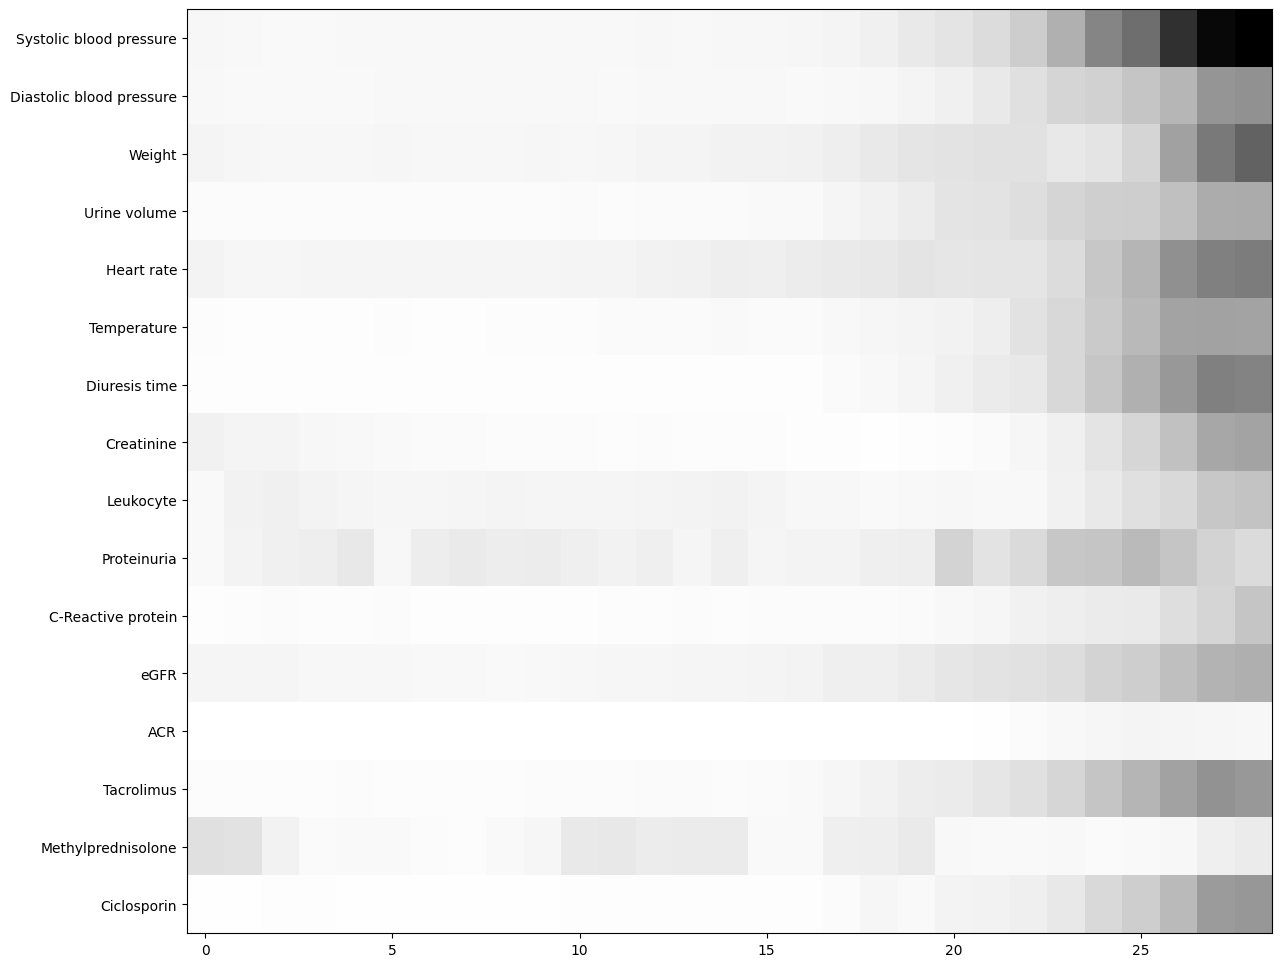

In [39]:
#%%script false --no-raise-error
#Plot time segment importance
plt.figure(figsize=(14,12))

tmp = []
for item in res:
    _, y, _ = unflatten_tensors(item[0], item[1])
    #print(f"x.shape: {_.shape}, y.shape: {y.shape}") #: x.shape: torch.Size([1, 9]), y.shape: torch.Size([1, 258, 16]), z.shape: torch.Size([1, 262, 1024])
    #if y.shape[1] == 258:
    y = y[:,:29,:]
    tmp.append(y.abs())
    print(y.shape)

#patient_one = tmp[0].detach().squeeze(0).transpose(1,0).numpy()
all_patients = torch.cat(tmp, dim=0).mean(dim=0).detach().transpose(1,0).cpu().numpy()
#time_segment_attribution = torch.cat(tmp, dim=0).mean(dim=0).sum(dim=1).detach().unsqueeze(0).numpy()
#print(time_segment_attribution)
t_names = [feature_name_mapping[x] for x in feature_names[9:]]
plt.yticks(range(len(all_data[9:])), t_names)
plt.imshow(all_patients, cmap='binary', aspect='auto')
#plt.colorbar()
plt.show()

#plt.yticks([0], ["Importance"])
#plt.imshow(time_segment_attribution, cmap='viridis', aspect='auto')
#plt.colorbar()
#plt.show()

In [ ]:
%%script false --no-raise-error

# Utility cell to print example patient data. 
j = 0
for batch in test_dataloader:
        B = batch['static_categorical_features'].size(0)
        for i in range(B):
            if j >= 500:
                break
            
            sc = batch['static_categorical_features'][i:i+1]
            sn = batch['static_numerical_features'][i:i+1]
            tf = batch['ts_features'][i:i+1]
            t = batch['timesteps'][i:i+1]
            m = batch['mask'][i:i+1]
            nt = batch['notes_embeddings'][i:i+1]
            nt_timesteps = batch['notes_timesteps'][i:i+1]
            nt_mask = batch['notes_mask'][i:i+1]
            #print(CONFIG['static_numerical_cols'])
            #print(sorted_y[-9:])
            if tf.shape[1] > 300:
                print(tf.shape)
            j+=1


torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 442, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 380, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])
torch.Size([1, 339, 16])


{'144': 5.155975486559328e-06, '107': 5.205222350923577e-06, '811': 5.3004523579147644e-06, '164': 5.424135906650918e-06, '697': 5.52328765479615e-06, '459': 5.701737791241612e-06, '990': 5.7580318753025495e-06, '302': 5.828864232171327e-06, '768': 5.875933311472181e-06, '819': 5.916908776271157e-06, '295': 5.948820671619615e-06, '524': 6.198026767378906e-06, '388': 6.203196335263783e-06, '553': 6.2257968238554895e-06, '495': 6.284803930611815e-06, '492': 6.383706022461411e-06, '856': 6.424428192985943e-06, '813': 6.465944807132473e-06, '453': 6.641138952545589e-06, '79': 6.647363079537172e-06, '5': 6.7792680056300014e-06, '802': 6.801271410949994e-06, '571': 6.886024493724108e-06, '672': 7.026160801615333e-06, '154': 7.134588486223947e-06, '173': 7.137550710467622e-06, '85': 7.206016562122386e-06, '559': 7.214307515823748e-06, '226': 7.2254720180353615e-06, '721': 7.289222594408784e-06, '645': 7.33018805476604e-06, '808': 7.3422911555098835e-06, '556': 7.3737051025091205e-06, '660': 7

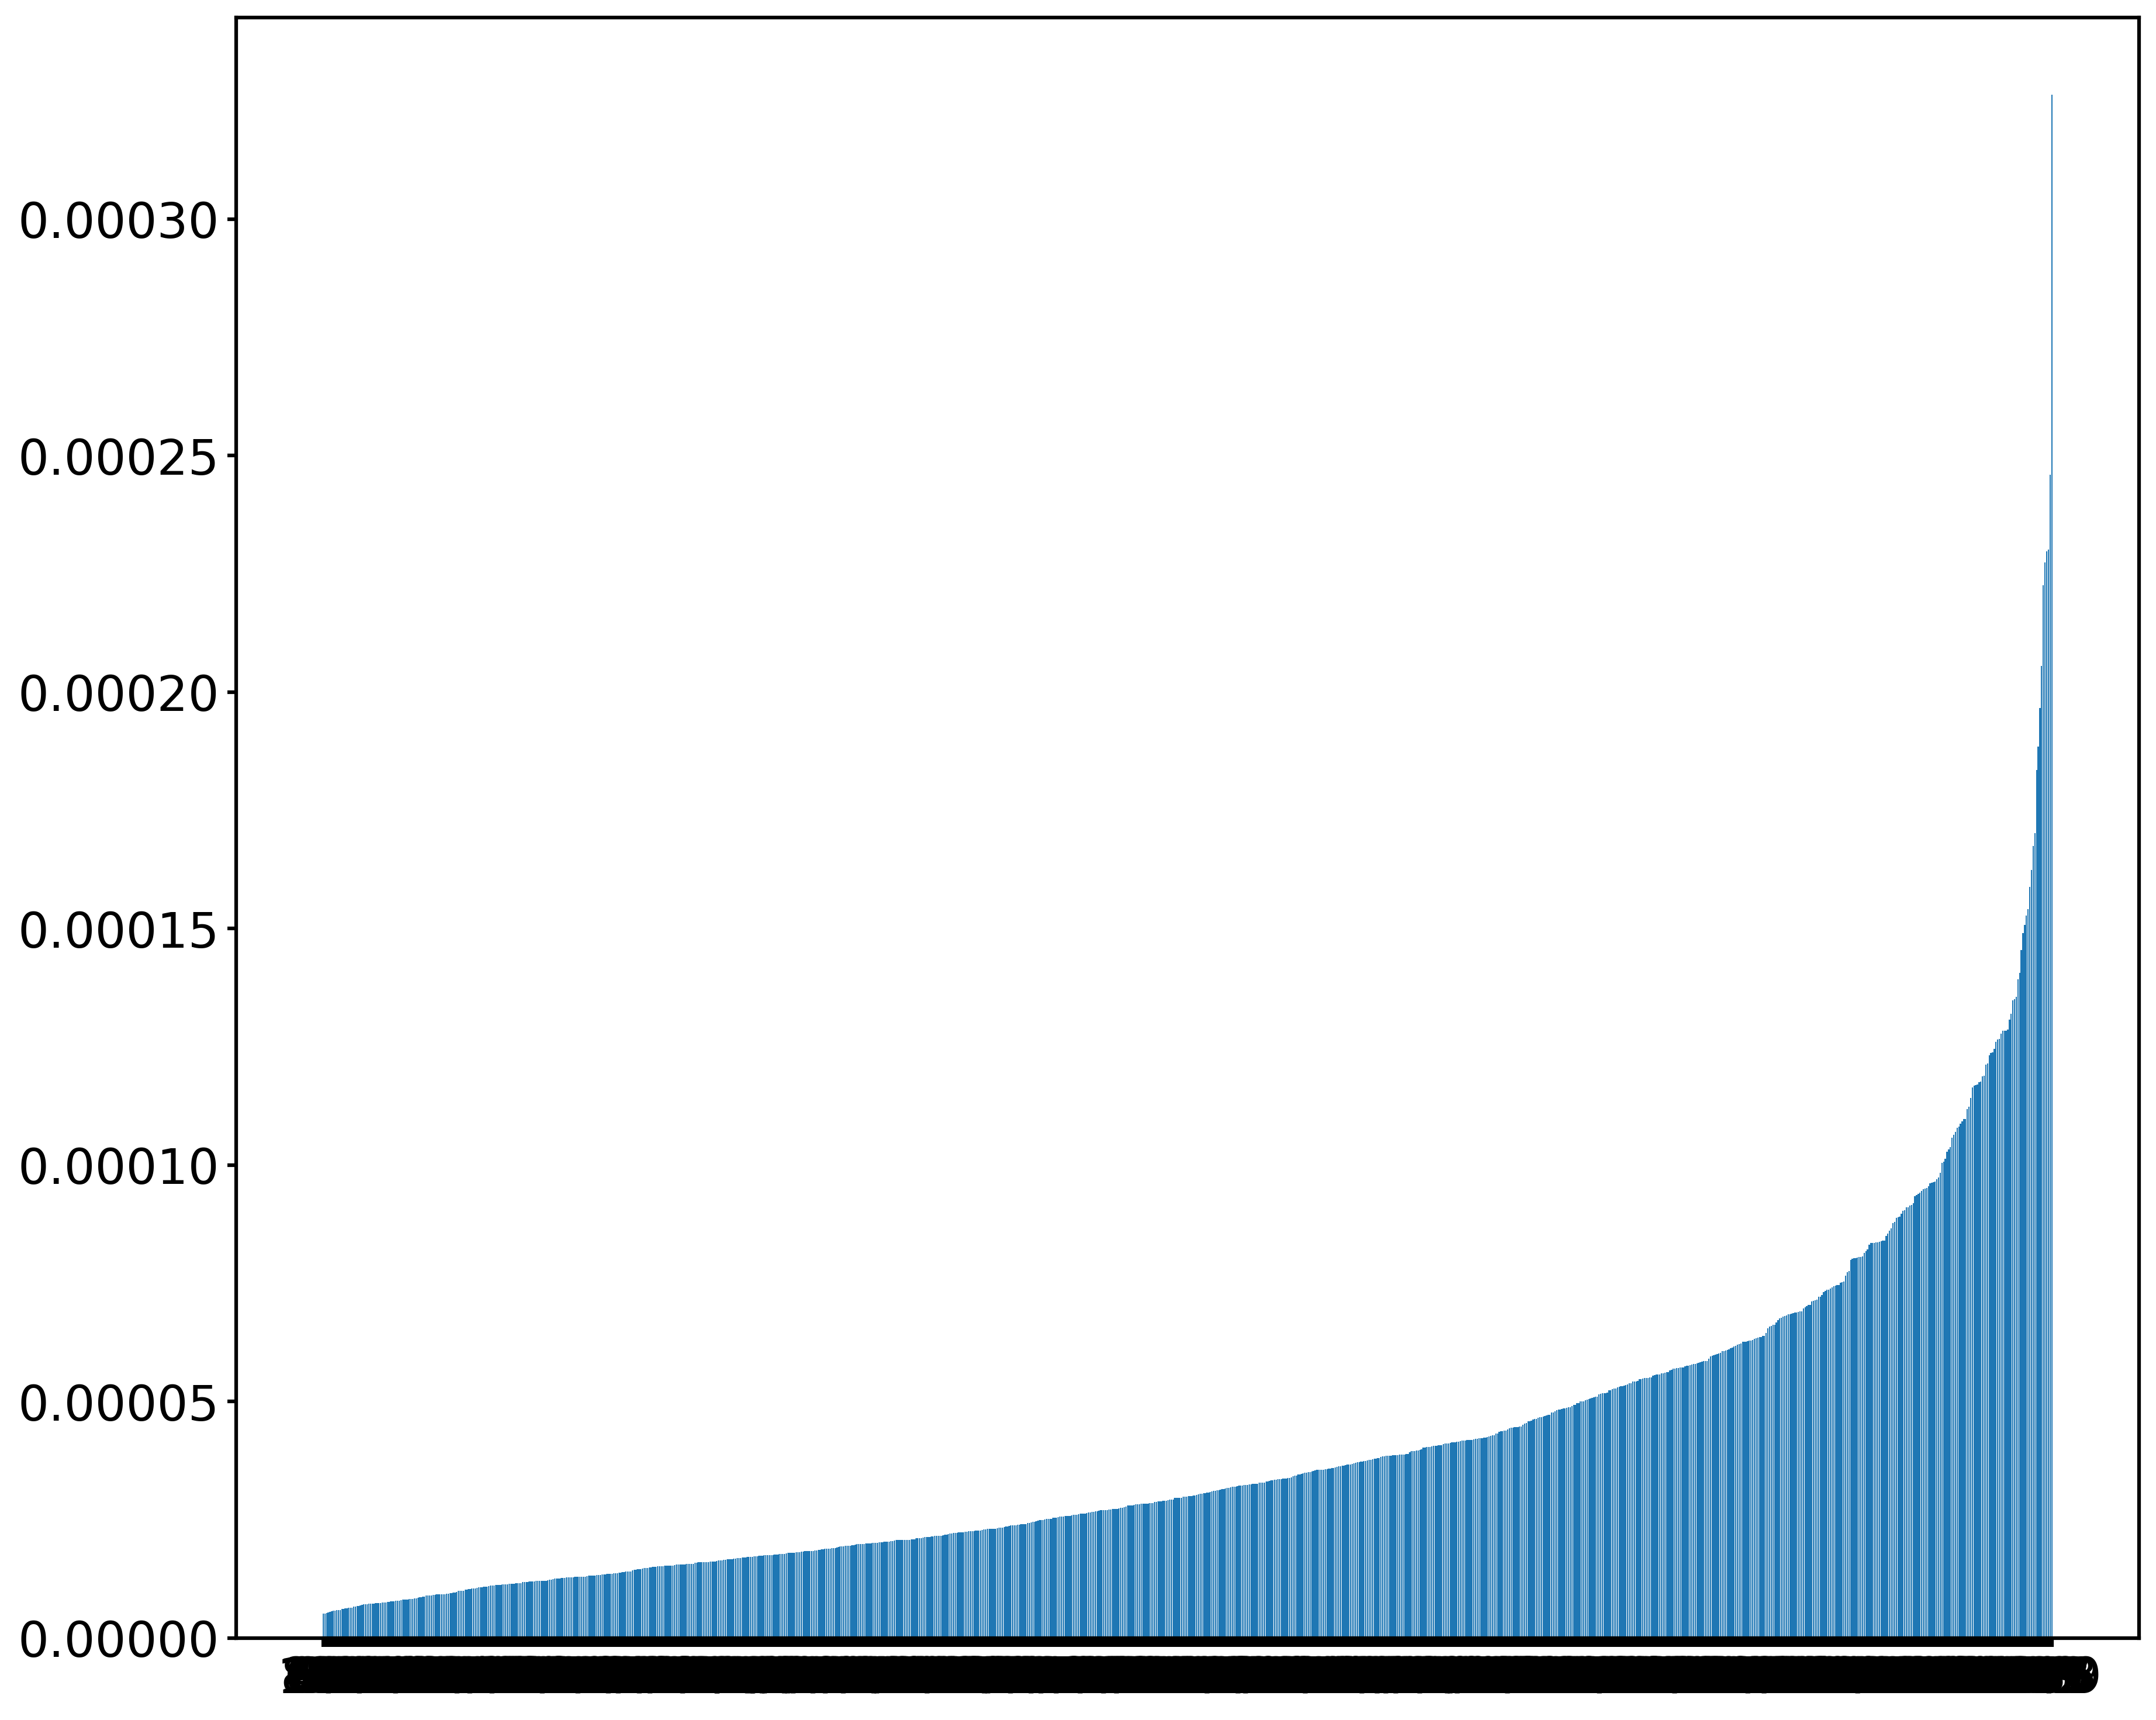

In [ ]:
%%script false --no-raise-error
emb_attributions = {}

for i, attr in enumerate(nt_mean):
    emb_attributions[i] = attr.item()

emb_attributions = {str(k): v for k, v in sorted(emb_attributions.items(), key=lambda item: item[1])}
print(emb_attributions)
plt.figure(figsize=(14,12))
plt.barh(emb_attributions.keys(), emb_attributions.values())
plt.show()